# WBGT Learning Module 2
## Read ERA5 data and calculate gridded African WBGT


### Data options

- `DATA_MODE = "synthetic"` runs immediately with a small teaching grid (no download).
- `DATA_MODE = "local"` opens an instructor-provided ERA5 Africa NetCDF file.
- **`DATA_MODE = "aws"` downloads and processes one week of *hourly* ERA5 over
  Africa from the public NSF-NCAR ERA5 bucket on AWS** and is the focus of this
  version of the notebook.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import wbgt_physics as wbgt

# ------------------------------------------------------------------
# Choose where the input data comes from.
#   "synthetic" : small teaching grid, runs instantly, no internet
#   "local"     : open an instructor-provided NetCDF file
#   "aws"       : download ONE WEEK of hourly ERA5 over Africa from the
#                 public nsf-ncar-era5 bucket (this lesson)
# ------------------------------------------------------------------
DATA_MODE = "aws"     

#LOCAL_ERA5_FILE = Path("data/era5_africa_3hourly.nc")

# ERA5 on AWS is HOURLY, so the averaging interval is 1 hour.
# The synthetic teaching grid is 3-hourly.
INTERVAL_HOURS = 1.0 if DATA_MODE == "aws" else 3.0

In [ ]:
# ----------------------------------------------------------------------
# AWS request settings (only used when DATA_MODE == "aws")
# ----------------------------------------------------------------------
AWS_BUCKET = "nsf-ncar-era5"     # public, anonymous access, us-west-2
AWS_REGION = "us-west-2"

# One week of hourly data (168 hourly time steps). Times are UTC.
# July is chosen because it is a hot season across much of Africa.
WEEK_START = "2020-07-01T00:00"
WEEK_END   = "2020-07-07T23:00"

# Africa bounding box in degrees, using the -180..180 longitude convention.
AFRICA_LAT = (-5.0, 25.0)
AFRICA_LON = (-20.0, 20.0)

# original spatial ranges
# AFRICA_LAT = (-37.0, 38.0)
# AFRICA_LON = (-20.0, 55.0)

# The pure-Python WBGT solver is not as fast as compiled Cython, so keep the
# teaching grid coarse. 1 = native 0.25 deg, 2 = 0.5 deg, 4 = 1.0 deg.
SPATIAL_STRIDE = 4

# Folder for any downloaded files and the saved result.
AWS_WORK_DIR = Path("era5_africa_week")

# True  : open each file from S3 and subset to Africa/week before loading
#         (recommended; keeps local disk small).
# False : download whole global files first, then subset
#         (simpler to reason about, but a much larger transfer).
USE_LAZY_S3 = True

## 1. Where the ERA5 variables live on AWS

The `nsf-ncar-era5` bucket stores one variable per file. Two families of
files matter here:

| File group | Variables we take | Nature |
|---|---|---|
| `e5.oper.an.sfc/` | `t2m`, `d2m`, `sp`, `u10`, `v10` | instantaneous analysis, valued at the top of each hour |
| `e5.oper.fc.sfc.meanflux/` | `msdwswrf`, `msnswrf`, `msdwlwrf`, `msnlwrf`, `msdrswrf` | hourly **mean fluxes**, already in W m⁻² |

Using the mean-flux radiation files means we do **not** have to de-accumulate
Joule-per-square-metre fields by hand.

Two real-world details this section handles for you:

1. **Longitude wrap.** ERA5 stores longitude as 0–360 with latitude
   descending. Africa straddles the 0° meridian, so we convert to −180…180
   and sort before subsetting.
2. **Forecast stream.** The mean-flux files are organised by
   `forecast_initial_time` × `forecast_hour` (initialised at 06 and 18 UTC).
   We reassemble them into a plain hourly time axis before use.

> **Data volume and speed.** Even one week over Africa is pulled out of global
> monthly / half-monthly files. The builder subsets to Africa and to the week
> *before* loading, so it stays lazy, but the bytes actually transferred still
> depend on each file's internal chunking — reading the analysis files is the
> slowest step. For your first run, set `WEEK_END` to one or two days and keep
> `SPATIAL_STRIDE` coarse to check the whole chain quickly, then widen to the
> full week. Setting `USE_LAZY_S3 = False` downloads whole files instead (more
> bytes, but a simple progress you can watch).

In [3]:
# Run once if these packages are missing (needed only for DATA_MODE == "aws").
# In a notebook you can uncomment the line below.
#%pip install -q s3fs h5netcdf boto3

### Look at the bucket structure

This cell is not required for the calculation. It just shows the top-level
layout so you can see where the file groups above come from.

In [4]:
RUN_AWS_BROWSE = False

if RUN_AWS_BROWSE:
    import s3fs

    fs = s3fs.S3FileSystem(anon=True)

    print("Top-level groups:")
    for entry in fs.ls(AWS_BUCKET)[:15]:
        print("  ", entry.split("/")[-1])

    print("\nExample surface-analysis files for 2020-07:")
    sample = fs.glob(f"{AWS_BUCKET}/e5.oper.an.sfc/202007/*128_167_2t*")
    for key in sample[:3]:
        print("  ", key.split("/")[-1])

## 2. Expected standardized ERA5 variables

Whatever the source, the rest of the notebook works with these readable names:

| Standardized name | ERA5 meaning | Unit |
|---|---|---|
| `t2m` | 2 m air temperature | K |
| `d2m` | 2 m dew point | K |
| `sp` | surface pressure | Pa |
| `u10`, `v10` | 10 m wind components | m s⁻¹ |
| `ssrd` | downward shortwave | W m⁻² |
| `ssr` | net shortwave | W m⁻² |
| `strd` | downward longwave | W m⁻² |
| `str` | net longwave | W m⁻² |
| `fdir_horizontal` | direct shortwave through a horizontal plane | W m⁻² |

The mean-flux radiation files are already interval-average W m⁻², so no
energy-to-flux conversion is needed. The helper is kept for the case where you
instead read accumulated `e5.oper.fc.sfc.accumu` files in J m⁻².

In [5]:
def accumulated_energy_to_flux(energy_j_m2, accumulation_seconds):
    """Convert accumulated energy (J m-2) to mean flux (W m-2).

    Not needed for the mean-flux files used below, which are already W m-2.
    Kept for the accumulated 'e5.oper.fc.sfc.accumu' path.
    """
    return energy_j_m2 / float(accumulation_seconds)


def standardize_coordinate_names(dataset):
    """Rename common coordinate variants to lat / lon / time."""
    rename = {}
    if "latitude" in dataset.coords:
        rename["latitude"] = "lat"
    if "longitude" in dataset.coords:
        rename["longitude"] = "lon"
    if "valid_time" in dataset.coords:
        rename["valid_time"] = "time"
    return dataset.rename(rename)

## 3. Create or open the input data

In [6]:
def make_synthetic_era5():
    """Small ERA5-like African grid for a reproducible lesson."""

    times = pd.date_range("2001-03-20T00:00", periods=24, freq="3h")

    lat = np.arange(-5.0, 16.0, 2.0)
    lon = np.arange(-15.0, 7.0, 2.0)

    full_cosine, sunlit_cosine = wbgt.solar_cosines(
        times.values, lat, lon, INTERVAL_HOURS
    )

    lon_2d, lat_2d = np.meshgrid(lon, lat)

    local_hour = (
        times.hour.to_numpy()[:, None, None] + lon_2d[None, :, :] / 15.0
    ) % 24.0

    diurnal = np.cos(2.0 * np.pi * (local_hour - 15.0) / 24.0)

    t2m = 301.5 + 4.2 * diurnal + 0.07 * (lat_2d[None, :, :] - 8.0)

    d2m = t2m - (5.0 + 0.18 * np.maximum(lat_2d[None, :, :] - 5.0, 0.0))

    sp = np.full_like(t2m, 100_000.0)

    u10 = np.full_like(t2m, 1.7) + 0.3 * np.sin(2.0 * np.pi * local_hour / 24.0)
    v10 = np.full_like(t2m, 0.8)

    ssrd = 900.0 * np.maximum(full_cosine, 0.0) ** 0.75

    albedo = 0.18
    ssr = ssrd * (1.0 - albedo)

    strd = 390.0 + 1.8 * (t2m - 300.0)

    sigma = 5.670374419e-8
    longwave_up = sigma * (t2m + 2.0) ** 4
    str_net = strd - longwave_up

    fdir_horizontal = 0.62 * ssrd

    return xr.Dataset(
        {
            "t2m": (("time", "lat", "lon"), t2m),
            "d2m": (("time", "lat", "lon"), d2m),
            "sp": (("time", "lat", "lon"), sp),
            "u10": (("time", "lat", "lon"), u10),
            "v10": (("time", "lat", "lon"), v10),
            "ssrd": (("time", "lat", "lon"), ssrd),
            "ssr": (("time", "lat", "lon"), ssr),
            "strd": (("time", "lat", "lon"), strd),
            "str": (("time", "lat", "lon"), str_net),
            "fdir_horizontal": (("time", "lat", "lon"), fdir_horizontal),
        },
        coords={"time": times, "lat": lat, "lon": lon},
        attrs={"warning": "Synthetic teaching data; not ERA5 observations."},
    )

### AWS builder: one week of hourly ERA5 over Africa

The functions below:

1. find the exact files that overlap the requested week (by reading the date
   range in each key, not by assuming it),
2. open each file (lazily from S3, or after downloading),
3. subset to the Africa box and coarsen by `SPATIAL_STRIDE`,
4. reassemble the forecast-stream radiation onto an hourly time axis,
5. merge everything into one dataset with the standardized variable names.

In [7]:
# Instantaneous analysis-surface variables: (grib code, grid tag)
ANALYSIS_VARS = {
    "t2m": ("128_167_2t", "ll025sc"),
    "d2m": ("128_168_2d", "ll025sc"),
    "sp":  ("128_134_sp", "ll025sc"),
    "u10": ("128_165_10u", "ll025uv"),
    "v10": ("128_166_10v", "ll025uv"),
}

# Radiation as hourly MEAN FLUXES (W m-2). Standard name -> grib code_shortname.
MEANFLUX_VARS = {
    "ssrd":            "235_035_msdwswrf",  # mean surface downward shortwave
    "ssr":             "235_037_msnswrf",   # mean surface net shortwave
    "strd":            "235_036_msdwlwrf",  # mean surface downward longwave
    "str":             "235_038_msnlwrf",   # mean surface net longwave
    "fdir_horizontal": "235_058_msdrswrf",  # mean surface direct shortwave
}


def _s3fs():
    import s3fs
    return s3fs.S3FileSystem(anon=True)


def _months_covering(start, end):
    """Year-months touching [start, end], plus the prior month.

    The prior month is included because a forecast-stream file can straddle a
    month boundary (e.g. the file ending 07-01 06Z supplies 07-01 00-05Z).
    """
    first = pd.Timestamp(start) - pd.Timedelta(days=20)
    months = pd.period_range(first, pd.Timestamp(end), freq="M")
    return sorted({m.strftime("%Y%m") for m in months})


def _key_date_range(key):
    """Parse the trailing START_END datetimes from a file key."""
    fields = key.split("/")[-1].split(".")
    start_str, end_str = fields[-2].split("_")
    fmt = "%Y%m%d%H"
    return (
        pd.to_datetime(start_str, format=fmt),
        pd.to_datetime(end_str, format=fmt),
    )


def find_overlapping_keys(fs, group, code):
    """List files in a group whose time span overlaps the requested week."""
    week_start = pd.Timestamp(WEEK_START)
    week_end = pd.Timestamp(WEEK_END)

    candidates = []
    for ym in _months_covering(WEEK_START, WEEK_END):
        candidates += fs.glob(f"{AWS_BUCKET}/{group}/{ym}/*{code}*")

    kept = []
    for key in sorted(set(candidates)):
        file_start, file_end = _key_date_range(key)
        if file_start <= week_end and file_end >= week_start:
            kept.append(key)
    return kept


def open_key(fs, key):
    """Open one file lazily from S3, or download then open."""
    if USE_LAZY_S3:
        return xr.open_dataset(fs.open(key), engine="h5netcdf", chunks={})
    AWS_WORK_DIR.mkdir(parents=True, exist_ok=True)
    local = AWS_WORK_DIR / Path(key).name
    if not local.exists():
        fs.get(key, str(local))
    return xr.open_dataset(local, engine="h5netcdf", chunks={})


def main_dataarray(dataset):
    """Pick the single geophysical field in a one-variable ERA5 file."""
    name = max(dataset.data_vars, key=lambda v: dataset[v].ndim)
    return dataset[name]


def to_africa_grid(dataarray):
    """Rename coords, fix the longitude wrap, subset Africa, coarsen.

    Subsetting is done by integer index in the file's native ordering, so we
    never sort or load the whole global array. Only the small Africa block is
    reordered afterwards. This keeps the remote read lazy and small.
    """
    da = standardize_coordinate_names(dataarray.to_dataset(name="_v"))["_v"]

    # Relabel longitude to -180..180 (just changes coordinate values, no load).
    if float(da["lon"].max()) > 180.0:
        da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180))

    # Integer indices of the Africa rows/cols. np.where on the 1-D coordinate
    # arrays handles the 0-meridian seam and the descending latitude without
    # requiring a monotonic axis or a global sort.
    lat_vals = da["lat"].values
    lon_vals = da["lon"].values
    lat_idx = np.where((lat_vals >= AFRICA_LAT[0]) & (lat_vals <= AFRICA_LAT[1]))[0]
    lon_idx = np.where((lon_vals >= AFRICA_LON[0]) & (lon_vals <= AFRICA_LON[1]))[0]

    da = da.isel(lat=lat_idx, lon=lon_idx).sortby("lat").sortby("lon")

    if SPATIAL_STRIDE > 1:
        da = da.isel(
            lat=slice(None, None, SPATIAL_STRIDE),
            lon=slice(None, None, SPATIAL_STRIDE),
        )
    return da


def forecast_to_hourly(dataarray):
    """Turn a forecast-stream field into a plain hourly valid-time series.

    NSF-NCAR forecast files are initialised at 06 and 18 UTC. Taking
    forecast_hour 1..12 from each initialisation tiles all 24 hours with no
    gaps or overlaps. If the file already exposes a flat time axis, it is
    returned unchanged.
    """
    dims = set(dataarray.dims)
    if {"forecast_initial_time", "forecast_hour"} <= dims:
        fh = dataarray["forecast_hour"]
        dataarray = dataarray.sel(forecast_hour=fh[(fh >= 1) & (fh <= 12)])
        stacked = dataarray.stack(
            time=("forecast_initial_time", "forecast_hour")
        )
        valid_time = (
            stacked["forecast_initial_time"].values
            + stacked["forecast_hour"].values * np.timedelta64(1, "h")
        )
        stacked = stacked.reset_index("time", drop=True)
        dataarray = stacked.assign_coords(time=("time", valid_time))
    return dataarray.sortby("time")


def _concat_week(parts):
    """Concatenate file parts in time, drop duplicate hours, cut to the week."""
    da = parts[0] if len(parts) == 1 else xr.concat(parts, dim="time")
    da = da.sortby("time")
    _, unique_idx = np.unique(da["time"].values, return_index=True)
    da = da.isel(time=unique_idx)
    da = da.sel(time=slice(WEEK_START, WEEK_END))
    # Forecast-stream reassembly leaves time as the trailing dim; make every
    # variable (time, lat, lon) so radiation and analysis fields agree.
    return da.transpose("time", "lat", "lon")


def build_era5_from_aws():
    """Assemble one week of hourly ERA5 over Africa into a standardized dataset."""
    fs = _s3fs()
    data_vars = {}

    print("Instantaneous analysis variables:")
    for std_name, (code, _grid) in ANALYSIS_VARS.items():
        keys = find_overlapping_keys(fs, "e5.oper.an.sfc", code)
        print(f"  {std_name:16s} <- {len(keys)} file(s)")
        parts = [to_africa_grid(main_dataarray(open_key(fs, k))) for k in keys]
        data_vars[std_name] = _concat_week(parts).rename(std_name)

    print("Mean-flux radiation variables:")
    for std_name, code in MEANFLUX_VARS.items():
        keys = find_overlapping_keys(fs, "e5.oper.fc.sfc.meanflux", code)
        print(f"  {std_name:16s} <- {len(keys)} file(s)")
        parts = [
            forecast_to_hourly(to_africa_grid(main_dataarray(open_key(fs, k))))
            for k in keys
        ]
        data_vars[std_name] = _concat_week(parts).rename(std_name)

    # Align every field onto the analysis hourly time axis.
    # reference_time = data_vars["t2m"]["time"]
    # aligned = {}
    # for name, da in data_vars.items():
    #     if da["time"].equals(reference_time):
    #         aligned[name] = da
    #     else:
    #         aligned[name] = da.reindex(
    #             time=reference_time,
    #             method="nearest",
    #             tolerance=pd.Timedelta("1h"),
    #         )


    # Align every field onto the analysis hourly time axis.
    reference_time = data_vars["t2m"]["time"]
    aligned = {}
    
    for name, da in data_vars.items():
        if da["time"].equals(reference_time):
            aligned[name] = da
        elif len(da["time"]) == len(reference_time):
            # O(1) coordinate replacement: skips expensive data copying and keeps arrays lazy
            aligned[name] = da.assign_coords(time=reference_time)
        else:
            # Fallback only if temporal dimensions genuinely mismatch
            aligned[name] = da.reindex(
                time=reference_time,
                method="nearest",
                tolerance=pd.Timedelta("1h"),
            )
        
    dataset = xr.Dataset(aligned).transpose("time", "lat", "lon").load()
    dataset.attrs["source"] = "NSF-NCAR ERA5 (nsf-ncar-era5) on AWS"
    dataset.attrs["week"] = f"{WEEK_START} to {WEEK_END} (hourly)"
    dataset.attrs["spatial_stride"] = SPATIAL_STRIDE
    return dataset

### Load the data for the selected mode

In [8]:
if DATA_MODE == "synthetic":
    era5 = make_synthetic_era5()
elif DATA_MODE == "local":
    era5 = standardize_coordinate_names(xr.open_dataset(LOCAL_ERA5_FILE))
elif DATA_MODE == "aws":
    era5 = build_era5_from_aws()
else:
    raise ValueError("DATA_MODE must be 'synthetic', 'local', or 'aws'.")

era5

Instantaneous analysis variables:
  t2m              <- 1 file(s)
  d2m              <- 1 file(s)
  sp               <- 1 file(s)
  u10              <- 1 file(s)
  v10              <- 1 file(s)
Mean-flux radiation variables:
  ssrd             <- 2 file(s)
  ssr              <- 2 file(s)
  strd             <- 2 file(s)
  str              <- 2 file(s)
  fdir_horizontal  <- 2 file(s)


<xarray.Dataset> Size: 39MB
Dimensions:          (lat: 76, time: 168, lon: 76)
Coordinates:
  * lat              (lat) float64 608B -37.0 -36.0 -35.0 ... 36.0 37.0 38.0
  * time             (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T23:0...
  * lon              (lon) float64 608B -20.0 -19.0 -18.0 ... 53.0 54.0 55.0
Data variables:
    t2m              (time, lat, lon) float32 4MB 286.5 286.5 ... 300.9 299.5
    d2m              (time, lat, lon) float32 4MB 282.7 282.6 ... 273.9 283.0
    sp               (time, lat, lon) float32 4MB 1.014e+05 ... 9.946e+04
    u10              (time, lat, lon) float32 4MB 14.64 15.22 ... -3.245 -2.409
    v10              (time, lat, lon) float32 4MB 1.186 0.05679 ... -1.654 2.182
    ssrd             (time, lat, lon) float32 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ssr              (time, lat, lon) float32 4MB 1e-15 1e-15 ... 1e-15 1e-15
    strd             (time, lat, lon) float32 4MB 315.2 313.3 ... 357.7 356.2
    str              (time, lat, lon) float32 4MB -74.56 -73.46 ... -83.76
    fdir_horizontal  (time, lat, lon) float32 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    source:          NSF-NCAR ERA5 (nsf-ncar-era5) on AWS
    week:            2020-07-01T00:00 to 2020-07-07T23:00 (hourly)
    spatial_stride:  4

## 4. Audit required variables and units

The same checks run for every data source. If an AWS file ever changes its
internal variable or coordinate names, this is where it will show up.

In [9]:
required = [
    "t2m", "d2m", "sp", "u10", "v10",
    "ssrd", "ssr", "strd", "str", "fdir_horizontal",
]

missing = [name for name in required if name not in era5]
if missing:
    raise KeyError(f"Missing required variables: {missing}")

audit = pd.DataFrame({
    "minimum": {name: float(era5[name].min()) for name in required},
    "maximum": {name: float(era5[name].max()) for name in required},
    "units attribute": {
        name: era5[name].attrs.get("units", "inspect source metadata")
        for name in required
    },
})

audit

,minimum,maximum,units attribute
t2m,2.677845e+02,322.606171,K
d2m,2.405154e+02,304.685516,K
sp,7.200902e+04,103163.609375,Pa
u10,-1.306479e+01,20.456818,m s**-1
v10,-1.874405e+01,20.473099,m s**-1
ssrd,0.000000e+00,1071.062500,W m**-2
ssr,9.999997e-16,982.656250,W m**-2
strd,1.948353e+02,505.722931,W m**-2
str,-3.290354e+02,7.404541,W m**-2
fdir_horizontal,0.000000e+00,912.109375,W m**-2


In [10]:
assert 240.0 < float(era5["t2m"].min()) < 340.0
assert 50_000.0 < float(era5["sp"].min()) < 110_000.0
assert float(era5["ssrd"].min()) >= 0.0

print("Basic range checks passed.")

Basic range checks passed.


## 5. Derive the physical inputs

In [11]:
relative_humidity = xr.DataArray(
    wbgt.relative_humidity_from_dewpoint(
        era5["t2m"].values, era5["d2m"].values, era5["sp"].values,
    ),
    dims=era5["t2m"].dims,
    coords=era5["t2m"].coords,
    name="relative_humidity",
)

wind_10m = np.hypot(era5["u10"], era5["v10"])

shortwave_up = era5["ssrd"] - era5["ssr"]
longwave_up = era5["strd"] - era5["str"]

direct_fraction = xr.where(
    era5["ssrd"] > 0.0,
    era5["fdir_horizontal"] / era5["ssrd"],
    0.0,
).clip(0.0, 0.9)

full_cosine_np, sunlit_cosine_np = wbgt.solar_cosines(
    era5["time"].values, era5["lat"].values, era5["lon"].values, INTERVAL_HOURS,
)

full_cosine = xr.DataArray(
    full_cosine_np, dims=("time", "lat", "lon"), coords=era5["t2m"].coords,
)
sunlit_cosine = xr.DataArray(
    sunlit_cosine_np, dims=("time", "lat", "lon"), coords=era5["t2m"].coords,
)

low_sun = full_cosine <= np.cos(np.deg2rad(89.5))
direct_fraction = xr.where(low_sun, 0.0, direct_fraction)

derived = xr.Dataset({
    "relative_humidity": relative_humidity,
    "wind_10m": wind_10m,
    "shortwave_up": shortwave_up,
    "longwave_up": longwave_up,
    "direct_fraction": direct_fraction,
    "full_cosine": full_cosine,
    "sunlit_cosine": sunlit_cosine,
})

derived

<xarray.Dataset> Size: 39MB
Dimensions:            (lat: 76, time: 168, lon: 76)
Coordinates:
  * lat                (lat) float64 608B -37.0 -36.0 -35.0 ... 36.0 37.0 38.0
  * time               (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T23...
  * lon                (lon) float64 608B -20.0 -19.0 -18.0 ... 53.0 54.0 55.0
Data variables:
    relative_humidity  (time, lat, lon) float64 8MB 77.61 77.49 ... 17.35 35.6
    wind_10m           (time, lat, lon) float32 4MB 14.69 15.22 ... 3.643 3.251
    shortwave_up       (time, lat, lon) float32 4MB -1e-15 -1e-15 ... -1e-15
    longwave_up        (time, lat, lon) float32 4MB 389.8 386.8 ... 447.3 440.0
    direct_fraction    (time, lat, lon) float32 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    full_cosine        (time, lat, lon) float64 8MB -0.9247 -0.9289 ... -0.3201
    sunlit_cosine      (time, lat, lon) float64 8MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

## 6. Calculate WBGT

In [12]:
def calculate_dataset_wbgt(meteorology, derived_inputs):
    answer = wbgt.calculate_wbgt(
        air_temperature_k=meteorology["t2m"].values,
        relative_humidity_pct=derived_inputs["relative_humidity"].values,
        pressure_pa=meteorology["sp"].values,
        wind_ms=derived_inputs["wind_10m"].values,
        shortwave_down_wm2=meteorology["ssrd"].values,
        shortwave_up_wm2=derived_inputs["shortwave_up"].values,
        longwave_down_wm2=meteorology["strd"].values,
        longwave_up_wm2=derived_inputs["longwave_up"].values,
        direct_fraction=derived_inputs["direct_fraction"].values,
        sunlit_cosine=derived_inputs["sunlit_cosine"].values,
        wind_height_m=10,
    )

    coordinates = meteorology["t2m"].coords
    dimensions = meteorology["t2m"].dims

    return xr.Dataset({
        "natural_wet_bulb_c": xr.DataArray(
            answer.natural_wet_bulb_c, dims=dimensions, coords=coordinates,
        ),
        "globe_temperature_c": xr.DataArray(
            answer.globe_temperature_c, dims=dimensions, coords=coordinates,
        ),
        "wbgt_outdoor_c": xr.DataArray(
            answer.wbgt_c, dims=dimensions, coords=coordinates,
        ),
        "wind_2m_ms": xr.DataArray(
            answer.wind_2m_ms, dims=dimensions, coords=coordinates,
        ),
    })


wbgt_fields = calculate_dataset_wbgt(era5, derived)
wbgt_fields

<xarray.Dataset> Size: 31MB
Dimensions:              (lat: 76, time: 168, lon: 76)
Coordinates:
  * lat                  (lat) float64 608B -37.0 -36.0 -35.0 ... 36.0 37.0 38.0
  * time                 (time) datetime64[ns] 1kB 2020-07-01 ... 2020-07-07T...
  * lon                  (lon) float64 608B -20.0 -19.0 -18.0 ... 53.0 54.0 55.0
Data variables:
    natural_wet_bulb_c   (time, lat, lon) float64 8MB 11.08 11.05 ... 16.08
    globe_temperature_c  (time, lat, lon) float64 8MB 12.82 12.77 ... 24.41
    wbgt_outdoor_c       (time, lat, lon) float64 8MB 11.65 11.62 ... 17.3 18.77
    wind_2m_ms           (time, lat, lon) float64 8MB 9.822 10.18 ... 2.174

### Indoor WBGT

Saeed computes labor capacity for **both** outdoor and indoor conditions. Indoor
WBGT uses the same physics with **shortwave radiation set to zero** and **air speed
fixed at 1 m/s** (longwave kept).

In [13]:
def calculate_indoor_wbgt(meteorology, derived_inputs):
    """Indoor WBGT: no solar load, wind fixed at 1 m/s (Saeed 2.6.1)."""
    zeros = np.zeros_like(meteorology["t2m"].values)
    ones = np.ones_like(meteorology["t2m"].values)

    answer = wbgt.calculate_wbgt(
        air_temperature_k=meteorology["t2m"].values,
        relative_humidity_pct=derived_inputs["relative_humidity"].values,
        pressure_pa=meteorology["sp"].values,
        wind_ms=ones,                 # 1 m/s ...
        shortwave_down_wm2=zeros,
        shortwave_up_wm2=zeros,
        longwave_down_wm2=meteorology["strd"].values,
        longwave_up_wm2=derived_inputs["longwave_up"].values,
        direct_fraction=zeros,
        sunlit_cosine=zeros,
        wind_height_m=2,              # ... treated as the 2 m air speed directly
    )
    return xr.DataArray(
        answer.wbgt_c,
        dims=meteorology["t2m"].dims,
        coords=meteorology["t2m"].coords,
        name="wbgt_indoor_c",
    )


wbgt_indoor = calculate_indoor_wbgt(era5, derived)
print("Indoor vs outdoor daytime-mean WBGT (deg C):")
_day = era5["ssrd"] > 5.0
print("  outdoor:", round(float(wbgt_fields["wbgt_outdoor_c"].where(_day).mean()), 1))
print("  indoor :", round(float(wbgt_indoor.where(_day).mean()), 1))

Indoor vs outdoor daytime-mean WBGT (deg C):
  outdoor: 22.9
  indoor : 20.8


## 7. Inspect the gridded result

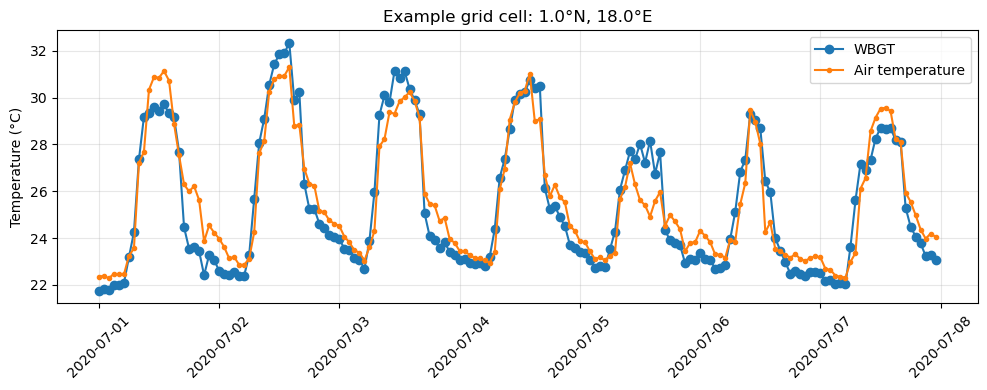

In [14]:
sample_lat = float(era5["lat"].values[len(era5["lat"]) // 2])
sample_lon = float(era5["lon"].values[len(era5["lon"]) // 2])

point = wbgt_fields.sel(lat=sample_lat, lon=sample_lon)

plt.figure(figsize=(10, 4))
plt.plot(point["time"], point["wbgt_outdoor_c"], marker="o", label="WBGT")
plt.plot(
    point["time"],
    era5["t2m"].sel(lat=sample_lat, lon=sample_lon) - 273.15,
    marker=".",
    label="Air temperature",
)
plt.ylabel("Temperature (°C)")
plt.title(f"Example grid cell: {sample_lat}°N, {sample_lon}°E")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

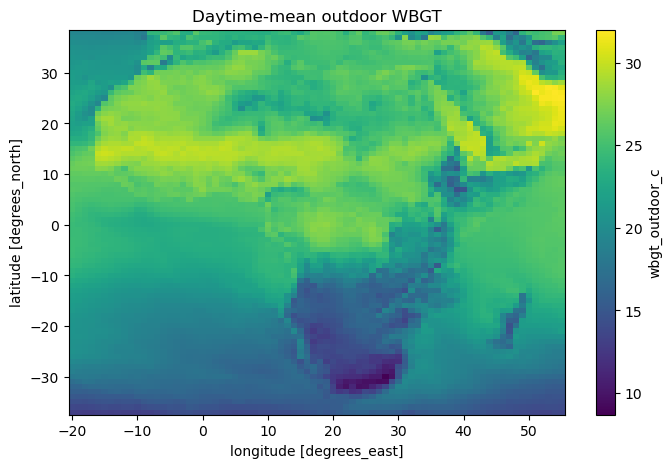

In [15]:
daylight = era5["ssrd"] > 5.0

daytime_mean = wbgt_fields["wbgt_outdoor_c"].where(daylight).mean("time")

plt.figure(figsize=(8, 5))
daytime_mean.plot()
plt.title("Daytime-mean outdoor WBGT")
plt.show()

## 8. Save a compact baseline product

In [ ]:
# if you run into file save error, please delete wbgt_outputs/era5_africa_wbgt_baseline_week.nc, and rerun this cell. The file is large and may be locked by another process.

baseline = xr.Dataset({
    "wbgt_outdoor_c": wbgt_fields["wbgt_outdoor_c"],
    "wbgt_indoor_c": wbgt_indoor,
    "rsds": era5["ssrd"],
})

baseline.attrs.update({
    "method": "Pure-Python explicit Liljegren WBGT (outdoor + indoor)",
    "data_mode": DATA_MODE,
    "period": str(era5.attrs.get("week", "one week (teaching)")),
    "note": "Baseline WBGT product for Notebook 4. Indoor: shortwave=0, wind=1 m/s.",
})

output_directory = Path("wbgt_outputs")
output_directory.mkdir(exist_ok=True)

suffix = "week" if DATA_MODE == "aws" else DATA_MODE
output_path = output_directory / f"era5_africa_wbgt_baseline_{suffix}.nc"

encoding = {v: {"zlib": True, "complevel": 4, "dtype": "float32"}
            for v in baseline.data_vars}
baseline.to_netcdf(output_path, engine="h5netcdf", encoding=encoding)

size_mb = output_path.stat().st_size / 1e6
print(f"Saved: {output_path.resolve()}  ({size_mb:.1f} MB)")

Saved: /Users/junghawoo/Documents/github/GLASSNET_ECR/wbgt_outputs/era5_africa_wbgt_baseline_week.nc  (8.0 MB)


## 8b. Export small per-country files (instructor step)

In [17]:
EXPORT_COUNTRIES = ["Ghana", "Nigeria", "Senegal", "Cameroon", "Burkina Faso"]
RUN_EXPORT = False   # set True to write the per-country files

if RUN_EXPORT:
    import regionmask

    for _v in ("natural_earth_v5_1_2", "natural_earth_v5_0_0", "natural_earth_v4_1_0"):
        if hasattr(regionmask.defined_regions, _v):
            countries = getattr(regionmask.defined_regions, _v).countries_110
            break

    country_mask = countries.mask(baseline["lon"], baseline["lat"], wrap_lon=False)
    country_dir = Path("wbgt_outputs/country")
    country_dir.mkdir(parents=True, exist_ok=True)

    def export_country(name, pad=0.5):
        number = next(n for n, nm in zip(countries.numbers, countries.names)
                      if nm.casefold() == name.casefold())
        inside = country_mask == number
        if int(inside.sum()) == 0:
            print(f"  {name}: no cell centers inside; skipped (grid too coarse).")
            return
        lat_in = baseline["lat"].where(inside.any("lon"), drop=True)
        lon_in = baseline["lon"].where(inside.any("lat"), drop=True)
        crop = baseline.sel(
            lat=slice(float(lat_in.min()) - pad, float(lat_in.max()) + pad),
            lon=slice(float(lon_in.min()) - pad, float(lon_in.max()) + pad),
        )
        safe = name.lower().replace(" ", "_").replace("'", "")
        path = country_dir / f"{safe}_wbgt_baseline.nc"
        enc = {v: {"zlib": True, "complevel": 4, "dtype": "float32"}
               for v in crop.data_vars}
        crop.to_netcdf(path, engine="h5netcdf", encoding=enc)
        print(f"  {name}: {crop.sizes['lat']}x{crop.sizes['lon']} cells, "
              f"{path.stat().st_size/1e6:.2f} MB -> {path.name}")

    print("Exporting country files:")
    for c in EXPORT_COUNTRIES:
        export_country(c)
else:
    print("RUN_EXPORT is False - set it True to write per-country files.")

RUN_EXPORT is False - set it True to write per-country files.


## 9. From one week to a production archive

The one-week workflow above is the whole pattern in miniature. To scale it up:

```python
for month in months:
    meteorology = build_month_from_aws(month)   # same find -> open -> subset
    derived = prepare_inputs(meteorology)
    month_wbgt = calculate_dataset_wbgt(meteorology, derived)
    month_wbgt.to_netcdf(output_file_for(month))
```

Validate a small sample first, inspect sunrise and sunset, and record the
source-file names, units, time conventions, code version, and root tolerance.

### Things to verify on your first real AWS run

1. Print one opened mean-flux file and confirm the `forecast_initial_time` /
   `forecast_hour` layout matches what `forecast_to_hourly` expects.
2. Confirm the analysis files give exactly 168 hourly steps for the week.
3. Check that longitudes span roughly −20 to 55 after the wrap fix.
4. Note the half-hour labeling difference between instantaneous analysis and
   interval-average mean fluxes; for hourly WBGT it is usually acceptable, but
   record the choice.

## References

- Kong, Q., & Huber, M. (2022). *Explicit calculations of wet-bulb globe temperature compared with approximations and why it matters for labor productivity*. Earth's Future, 10, e2021EF002334.
- Liljegren, J. C., et al. (2008). *Modeling the Wet Bulb Globe Temperature Using Standard Meteorological Measurements*. Journal of Occupational and Environmental Hygiene, 5, 645–655.
- NSF NCAR Curated ERA5 on AWS: `https://registry.opendata.aws/nsf-ncar-era5/`
- ERA5 parameter tables (NCAR ds633): `https://gdex.ucar.edu/datasets/d633001/metadata/grib.html`